Lese CASSY-2 Datei:  f_n Cassy.labx
Maximum peak found at:  413.0  Hz
Maximum peak found at:  818.0  Hz
Maximum peak found at:  1225.0  Hz
Maximum peak found at:  1632.0  Hz
Maximum peak found at:  2040.0  Hz


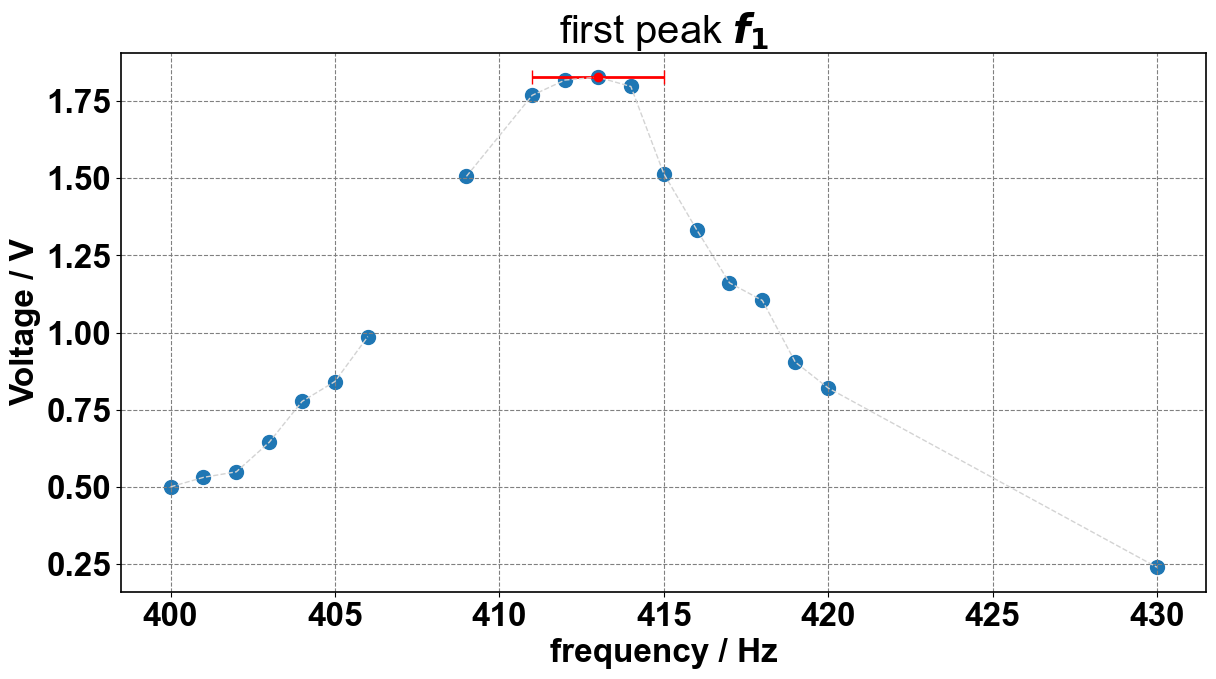

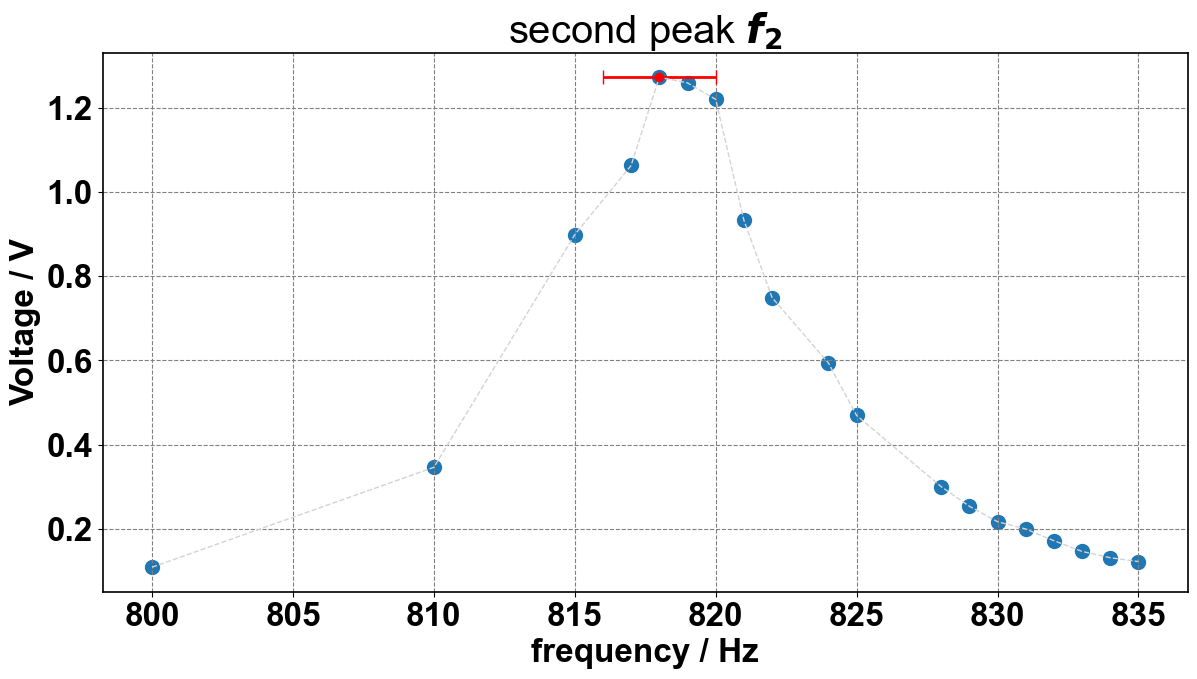

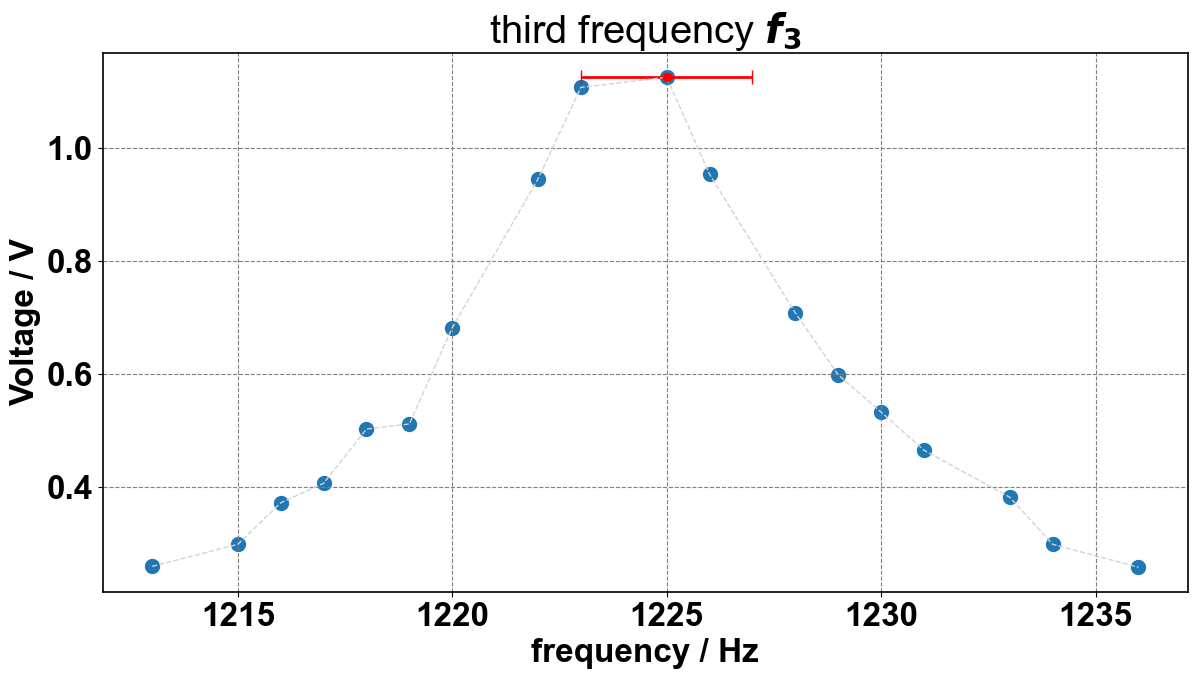

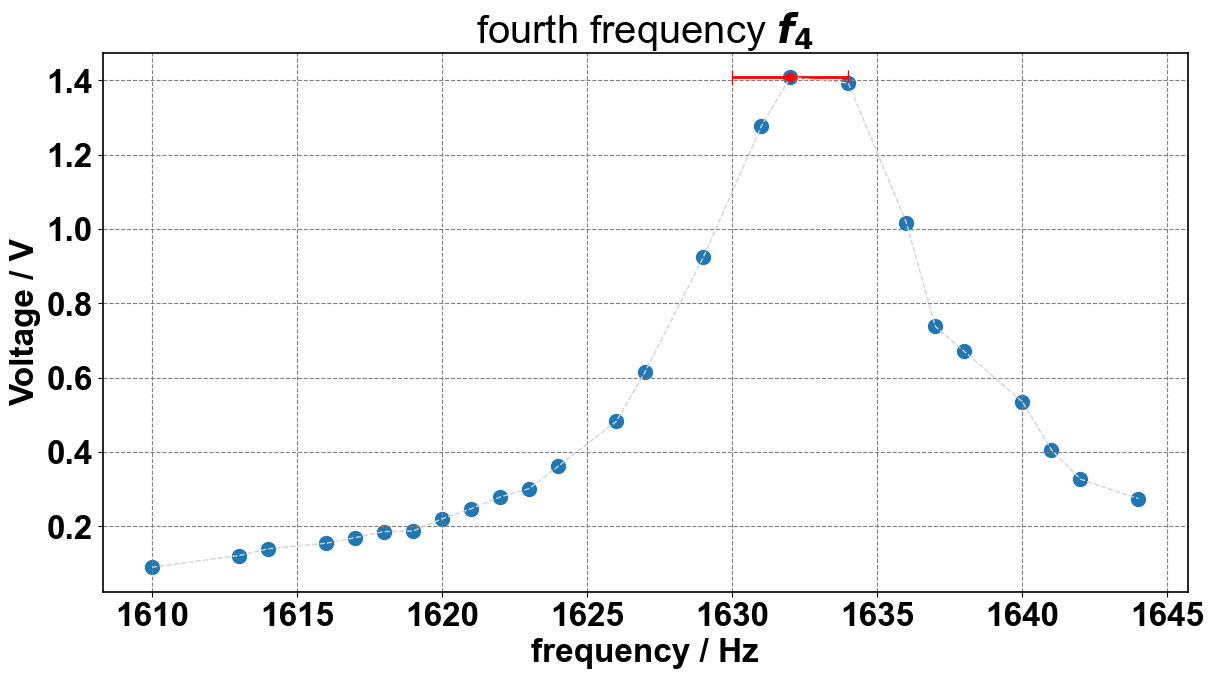

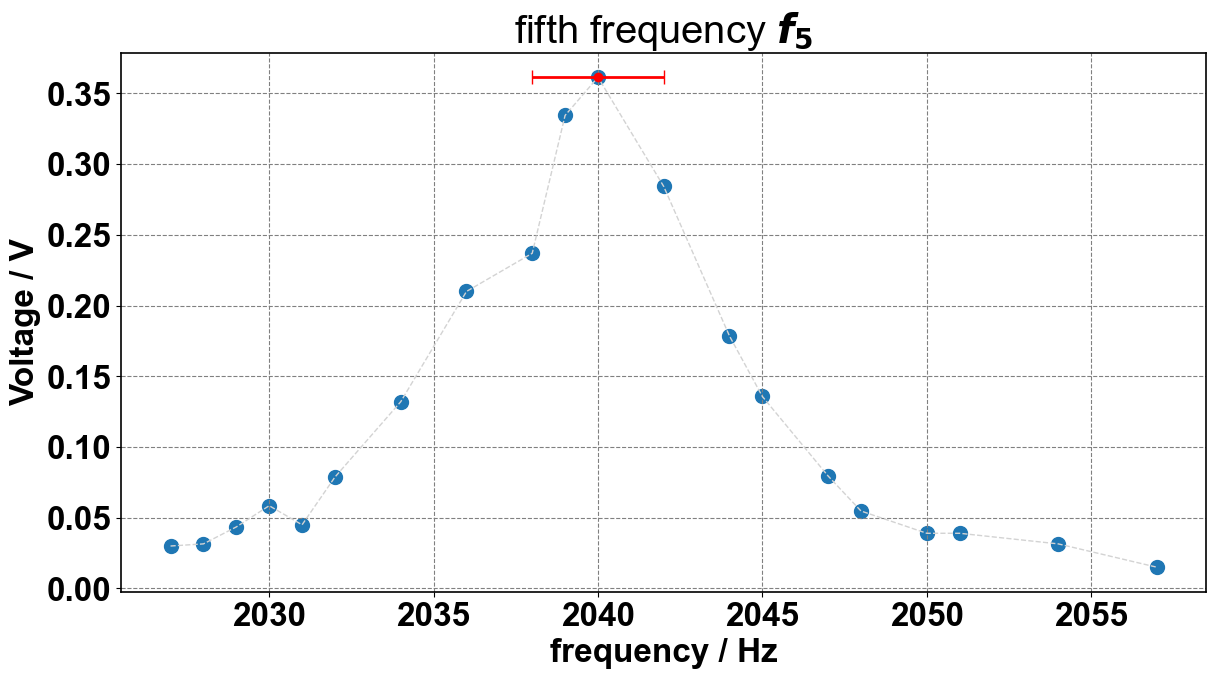

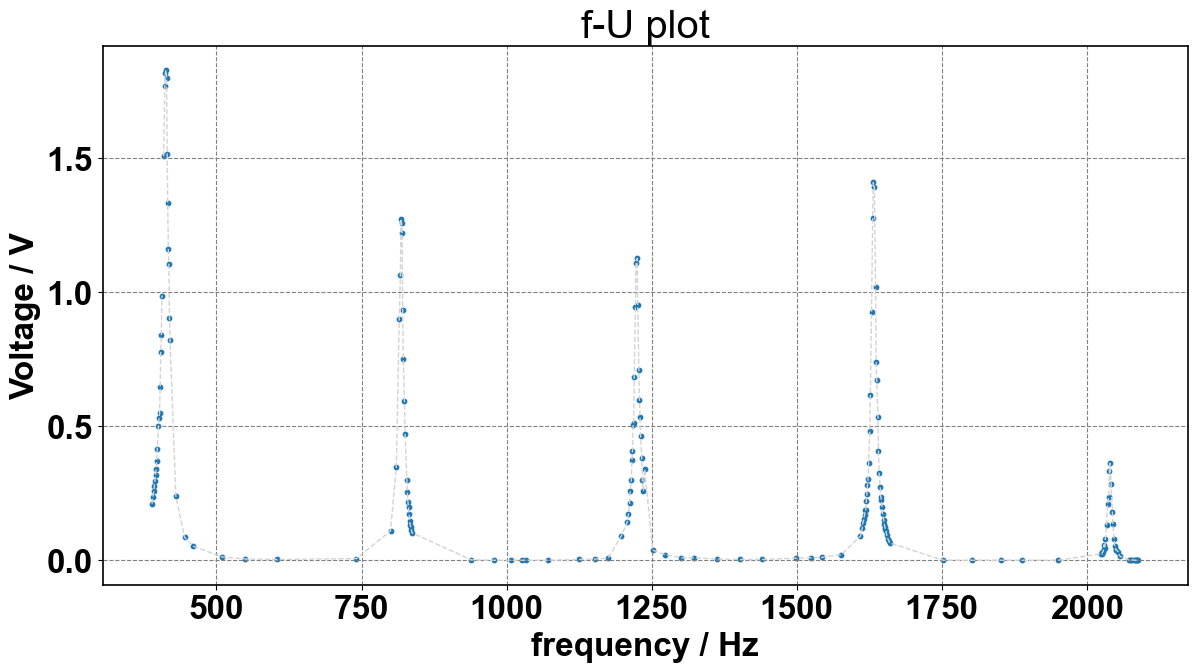

In [ ]:
from praktikum import analyse
from praktikum import cassy
import numpy as np
import matplotlib.pyplot as plt
from uncertainties import ufloat
from scipy.signal import find_peaks
 

plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 24.0
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelsize'] = 'medium'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['lines.linewidth'] = 2.0

file = "f_n Cassy.labx"
data = cassy.CassyDaten(file)
f = data.messung(1).datenreihe('f_B1').werte
U = data.messung(1).datenreihe('U_A1').werte

#sorting out the arrays
unique_f = np.unique(f)
u_means = []
for val in unique_f:
    mask = (f == val)    
    u_means.append(np.mean(U[mask]))
f = np.array(unique_f)
U = np.array(u_means)

peaks, props = find_peaks(U, height=0.2, distance=10)

for peak in peaks:
    print("Maximum peak found at: ",f[peak], " Hz")

sorted_pairs = sorted(zip(f, U))
f, U = zip(*sorted_pairs)
f_peak = f[peaks[0]]
u_peak = U[peaks[0]]
delta_f = 2  # Your chosen uncertainty
plt.errorbar(f_peak, u_peak, xerr=delta_f, 
            fmt='o', color='red', markersize=6, 
            capsize=5, elinewidth=2, label=r"Peak $\pm 2$ Hz")
plt.plot(f[10:30],U[10:30], color='lightgrey', linewidth=1, linestyle='--')
plt.scatter(f[10:30],U[10:30], s=100)
plt.xlabel("frequency / Hz")
plt.ylabel("Voltage / V")
plt.title("first peak $f_1$")
plt.grid(color='gray', linestyle='--')
plt.savefig("f_1.pdf")
plt.show()

#-------
f_peak = f[peaks[1]]
u_peak = U[peaks[1]]
delta_f = 2  # Your chosen uncertainty
plt.errorbar(f_peak, u_peak, xerr=delta_f, 
            fmt='o', color='red', markersize=6, 
            capsize=5, elinewidth=2, label=r"Peak $\pm 2$ Hz")

plt.plot(f[36:55],U[36:55], color='lightgrey', linewidth=1, linestyle='--')
plt.scatter(f[36:55],U[36:55], s=100)
plt.xlabel("frequency / Hz")
plt.ylabel("Voltage / V")
plt.title("second peak $f_2$")
plt.grid(color='gray', linestyle='--')
plt.savefig("f_2.pdf")
plt.show()

#-------

f_peak = f[peaks[2]]
u_peak = U[peaks[2]]
delta_f = 2  # Your chosen uncertainty
plt.errorbar(f_peak, u_peak, xerr=delta_f, 
            fmt='o', color='red', markersize=6, 
            capsize=5, elinewidth=2, label=r"Peak $\pm 2$ Hz")
plt.plot(f[70:88],U[70:88], color='lightgrey', linewidth=1, linestyle='--')
plt.scatter(f[70:88],U[70:88], s=100)
plt.xlabel("frequency / Hz")
plt.ylabel("Voltage / V")
plt.title("third frequency $f_3$")
plt.grid(color='gray', linestyle='--')
plt.savefig("f_3.pdf")
plt.show()

#------

a = 100
b = 125
f_peak = f[peaks[3]]
u_peak = U[peaks[3]]
delta_f = 2  # Your chosen uncertainty
plt.errorbar(f_peak, u_peak, xerr=delta_f, 
            fmt='o', color='red', markersize=6, 
            capsize=5, elinewidth=2, label=r"Peak $\pm 2$ Hz")

plt.plot(f[a:b],U[a:b], color='lightgrey', linewidth=1, linestyle='--')
plt.scatter(f[a:b],U[a:b], s=100)
plt.xlabel("frequency / Hz")
plt.ylabel("Voltage / V")
plt.title("fourth frequency $f_4$")
plt.grid(color='gray', linestyle='--')
plt.savefig("f_4.pdf")
plt.show()

#-------

a = 145
b = 165
f_peak = f[peaks[4]]
u_peak = U[peaks[4]]
delta_f = 2  # Your chosen uncertainty
plt.errorbar(f_peak, u_peak, xerr=delta_f, 
            fmt='o', color='red', markersize=6, 
            capsize=5, elinewidth=2, label=r"Peak $\pm 2$ Hz")

plt.plot(f[a:b],U[a:b], color='lightgrey', linewidth=1, linestyle='--')
plt.scatter(f[a:b],U[a:b], s=100)
plt.xlabel("frequency / Hz")
plt.ylabel("Voltage / V")
plt.title("fifth frequency $f_5$")
plt.grid(color='gray', linestyle='--')
plt.savefig("f_5.pdf")
plt.show()

plt.plot(f,U, color='lightgrey', linewidth=1, linestyle='--')
plt.scatter(f,U, s=10)
plt.xlabel("frequency / Hz")
plt.ylabel("Voltage / V")
plt.title("f-U plot")
plt.grid(color='gray', linestyle='--')
plt.savefig("f_u.pdf")
plt.show()


R = (406.8+/-0.6) Hz, b = (5.2+/-2.1) Hz, chi2/dof = 0.7 / 3,  corr = -0.904535


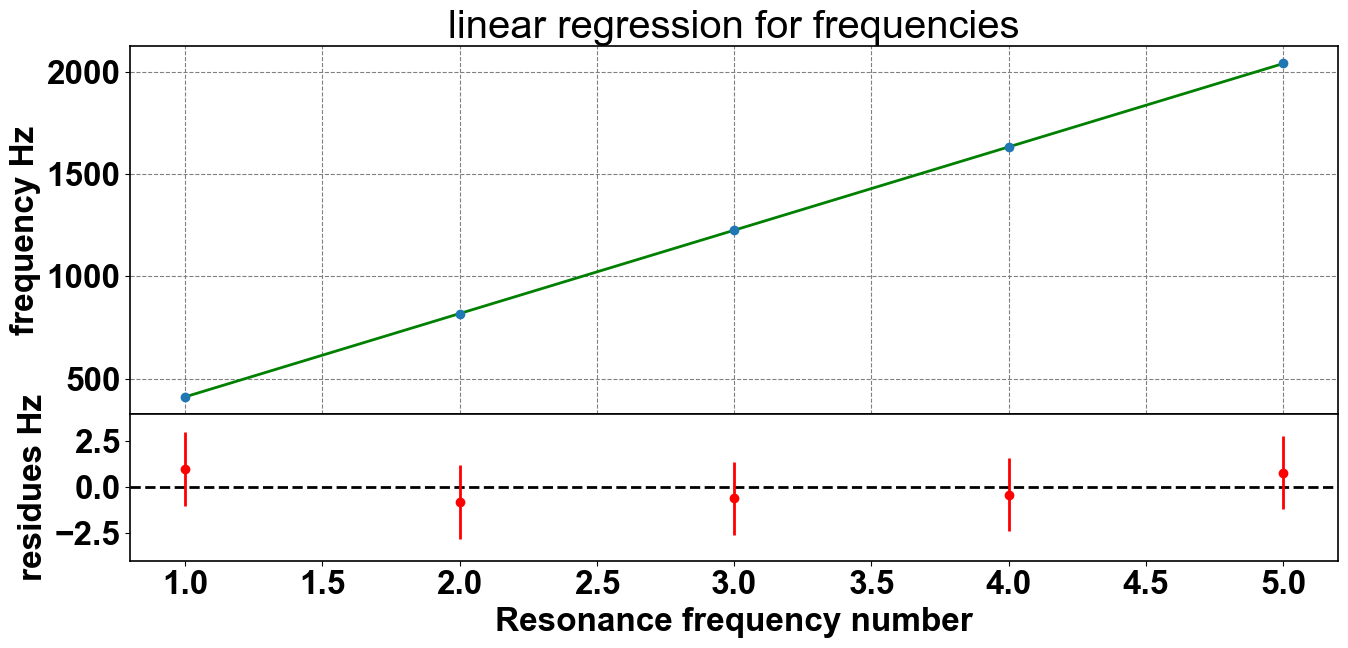

In [ ]:
f_1 = f[peaks[0]]
f_2 = f[peaks[1]]
f_3 = f[peaks[2]]
f_4 = f[peaks[3]]
f_5 = f[peaks[4]]
F = np.array([f_1, f_2, f_3, f_4, f_5])
n = np.array([1,2,3,4,5])
f_err = np.array([2, 2, 2, 2, 2])

fig, ax = plt.subplots(2, 1, sharex=True, gridspec_kw={'height_ratios': [5, 2]})
R, eR, b, eb, chiq, corr = analyse.lineare_regression_xy(n, F, ex = np.ones(5)*1E-10,  ey = f_err)
uR = ufloat(R, eR)
ub = ufloat(b, eb)
dof = len(n) - 2
print(f'R = ({uR}) Hz, b = ({ub}) Hz, chi2/dof = {chiq:.1f} / {dof},  corr = {corr:g}')
ax[0].plot(n, R*n+b, color='green')
ax[0].errorbar(n,F,yerr=f_err, fmt = "o")
ax[0].grid(color='gray', linestyle='--')
ax[0].set_ylabel('frequency Hz')
ax[0].set_title("linear regression for frequencies")

sigmaR = np.sqrt((f_err)**2)
ax[1].axhline(y=0., color='black', linestyle='--')
ax[1].errorbar(n, F - (R*n + b), yerr=sigmaR, color='red', fmt='o')
ax[1].set_xlabel('Resonance frequency number')
ax[1].set_ylabel('residues Hz')
ax[1].set_ylim(-4, 4)
plt.tight_layout()
fig.subplots_adjust(hspace=0.0)
plt.savefig("reg_f_1.pdf")
plt.show()



In [59]:
l = np.array([41.95, 42])
print(l.mean())

print(l.std(ddof=1))

41.975
0.03535533905932537


In [61]:
np.sqrt(0.35**2 + 0.07**2)

0.35693136595149494

In [69]:
f_avg = F/n
f_er = f_err/n

def calculate_weighted_mean(data, uncertainties):
    weights = 1.0 / (uncertainties**2)
    
    weighted_mean = np.sum(weights * data) / np.sum(weights)
    
    combined_std = np.sqrt(1.0 / np.sum(weights))
    
    return weighted_mean, combined_std


f_avg, f_er = calculate_weighted_mean(f_avg, f_er)

print(f_avg)
print(f_er)
f_n = ufloat(f_avg, f_er)
L = ufloat(41.975, 0.0357)

408.2181818181818
0.26967994498529685


In [72]:
v = f_n * 2 * L/100

In [73]:
v

342.6991636363636+/-0.36906470807583613

R = (406.80+/-0.32) Hz, b = (4.4+/-1.0) Hz, chi2/dof = 4.4 / 3,  corr = -0.904529


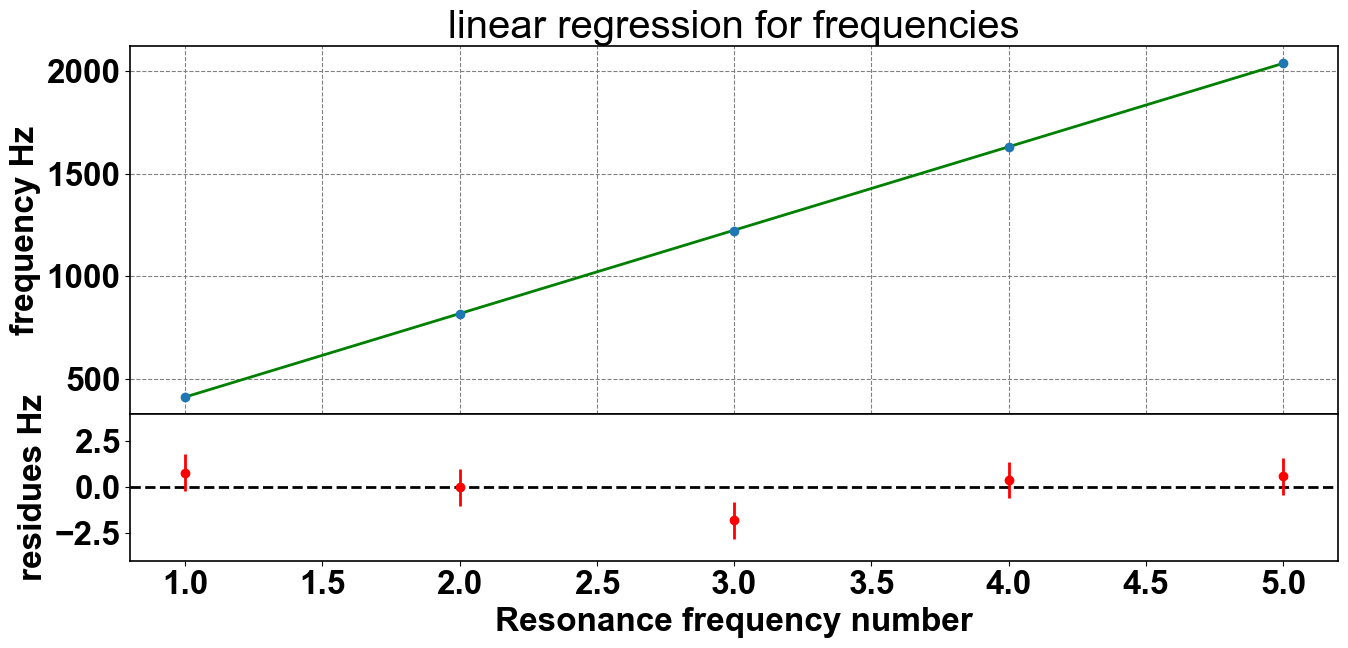

In [82]:

F = np.array([412, 818, 1223, 1632, 2039])
n = np.array([1,2,3,4,5])
f_err = np.array([1, 1, 1, 1, 1])

fig, ax = plt.subplots(2, 1, sharex=True, gridspec_kw={'height_ratios': [5, 2]})
R, eR, b, eb, chiq, corr = analyse.lineare_regression_xy(n, F, ex = np.ones(5)*1E-10,  ey = f_err)
uR = ufloat(R, eR)
ub = ufloat(b, eb)
dof = len(n) - 2
print(f'R = ({uR}) Hz, b = ({ub}) Hz, chi2/dof = {chiq:.1f} / {dof},  corr = {corr:g}')
ax[0].plot(n, R*n+b, color='green')
ax[0].errorbar(n,F,yerr=f_err, fmt = "o")
ax[0].grid(color='gray', linestyle='--')
ax[0].set_ylabel('frequency Hz')
ax[0].set_title("linear regression for frequencies")

sigmaR = np.sqrt((f_err)**2)
ax[1].axhline(y=0., color='black', linestyle='--')
ax[1].errorbar(n, F - (R*n + b), yerr=sigmaR, color='red', fmt='o')
ax[1].set_xlabel('Resonance frequency number')
ax[1].set_ylabel('residues Hz')
ax[1].set_ylim(-4, 4)
plt.tight_layout()
fig.subplots_adjust(hspace=0.0)
plt.savefig("reg_f_2.pdf")
plt.show()

